In [2]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

## FUNCTION DEFINITIONS

In [3]:
#Generates spins from spins.txt
def loadData():
    data = np.genfromtxt("spins.txt", dtype=int, delimiter=1)
    theta = data.astype(float) * np.pi
    phi = np.zeros_like(theta)
    L = data.shape[0]
    return theta,phi,L

In [5]:
#the avg x-compoennt of Spin Angle
def magnetization(theta):
    return np.mean(np.cos(theta))

In [6]:
def spinDot(theta1, phi1, theta2, phi2):
    return (np.cos(theta1)*np.cos(theta2) + np.sin(theta1)*np.sin(theta2)*np.cos(phi1 - phi2))

In [7]:
#the delta Energy of changing one of the node in the lattice
def delE(i,j,J,D,H,newTheta,newPhi):
    
    #Applying Periodic Boundary Conditions
    if i==0:
        up=L-1
    else:
        up=i-1
    if i==L-1:
        down = 0
    else:
        down = i+1
    if j==0:
        left=L-1
    else:
        left=j-1
    if j==L-1:
        right = 0
    else:
        right = j+1
        
    oldTheta = theta[i,j]
    oldPhi = phi[i,j]
    
    #Finding Energy old
    Eold = -J*(
        spinDot(oldTheta,oldPhi,theta[up,j], phi[up,j])
        + spinDot(oldTheta,oldPhi,theta[down,j], phi[down,j])
        + spinDot(oldTheta,oldPhi,theta[i,left], phi[i,left])
        + spinDot(oldTheta,oldPhi,theta[i,right], phi[i,right]))-(D*np.cos(oldTheta)**2)-H*np.cos(oldTheta)
       
    #Energy of proposed newAngle
    Enew = -J*(
        spinDot(newTheta,newPhi,theta[up,j], phi[up,j])
        + spinDot(newTheta,newPhi,theta[down,j], phi[down,j])
        + spinDot(newTheta,newPhi,theta[i,left], phi[i,left])
        + spinDot(newTheta,newPhi,theta[i,right], phi[i,right]))-(D*np.cos(newTheta)**2)-H*np.cos(newTheta)

    delE = Enew - Eold
    return delE

In [8]:
#Does L*L random checks and determines whether the Spin can change using 

def sweep(J,D,H,T):
    
    for x in range(L * L):
        i = rng.integers(0, L)
        j = rng.integers(0, L)

        Dij = D[i,j]
        oldTheta = theta[i,j]
        oldPhi = phi[i,j]

        
        u = rng.uniform(-1, 1)
        newTheta = np.arccos(u)
        newPhi = rng.uniform(0, 2*np.pi)
        
        dE = delE(i,j,J,Dij,H,newTheta,newPhi)
        if dE<= 0:
            theta[i,j] = newTheta
            phi[i,j] = newPhi
        elif T>0:
            P = (np.e)**(-dE/T)
            if rng.random() <= P:
                theta[i,j] = newTheta
                phi[i,j] = newPhi        

## Color Gradient of Spin Angles in Lattice

[[ 0. 10. 10. 10.  0.  0.  0.  0. 10.  0.]
 [ 0.  0. 10.  0.  0.  0. 10.  0.  0. 10.]
 [10. 10. 10.  0. 10. 10.  0.  0.  0. 10.]
 [ 0. 10.  0.  0.  0.  0. 10.  0.  0.  0.]
 [ 0.  0.  0. 10.  0.  0. 10.  0. 10. 10.]
 [ 0.  0. 10.  0.  0.  0. 10. 10.  0. 10.]
 [10. 10.  0. 10. 10. 10.  0.  0. 10. 10.]
 [ 0. 10.  0.  0. 10. 10. 10. 10. 10.  0.]
 [ 0. 10.  0.  0. 10. 10.  0. 10. 10.  0.]
 [ 0.  0. 10. 10.  0. 10.  0. 10. 10. 10.]]


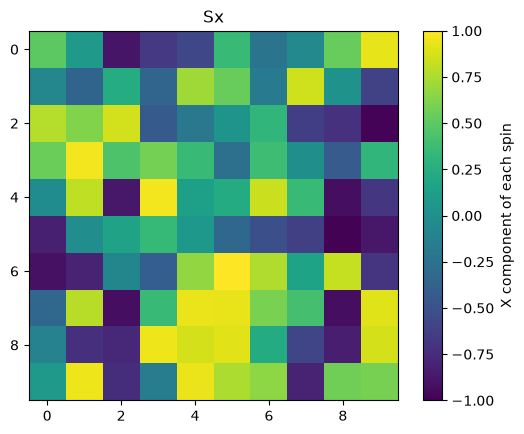

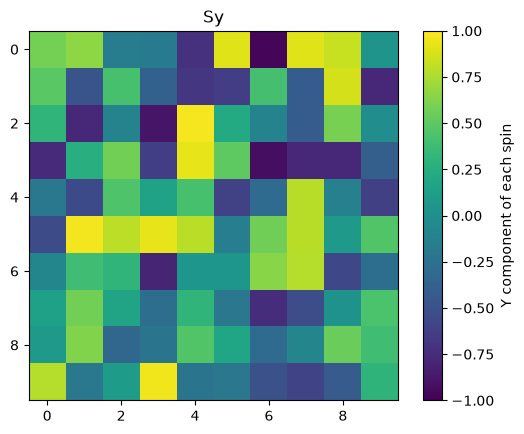

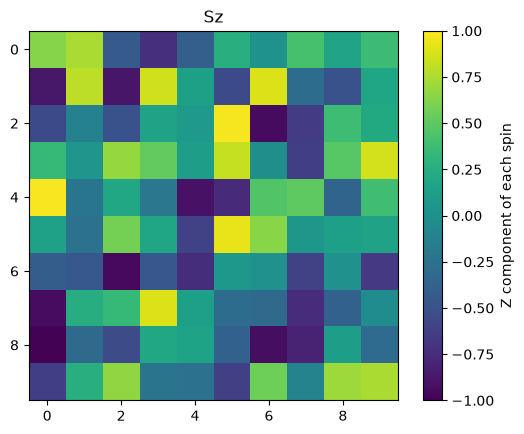

In [9]:
theta,phi,L = loadData()
J = 1.0 #Coupling Strength J 
T = 10 #Temperature
H = 0 #Magnetic Field Strength H 

p = 0.5
colspacing = 0
rowspacing = 0
Dmax = 10
Dmin = 0
D = DmapRandom(theta,p,Dmax,Dmin)
#D = DmapPeriodic(theta,colspacing,rowspacing, Dmax, Dmin)
#D = DmapCheckerboard(theta,Dmax,Dmin)
print(D)



#MonteCarlo Sweeps
for x in range(0,1000):
    sweep(J,D,H,T)

#x-component
plt.imshow(np.cos(theta), vmin=-1, vmax=1)
plt.colorbar(label="X component of each spin")
plt.title("Sx")
plt.show()

#y-component
plt.imshow(np.sin(theta) * np.cos(phi), vmin=-1, vmax=1)
plt.colorbar(label="Y component of each spin")
plt.title("Sy")
plt.show()

#z-component
plt.imshow(np.sin(theta) * np.sin(phi), vmin=-1, vmax=1)
plt.colorbar(label="Z component of each spin")
plt.title("Sz")
plt.show()

## Hysteresis Simulation

In [10]:
def findCoerciveField(HValues, MValues):
    for i in range(len(MValues) - 1):
        if MValues[i] == 0:
            return HValues[i]
        if MValues[i]*MValues[i + 1] < 0:
            H1 = HValues[i]
            H2 = HValues[i + 1]
            M1 = MValues[i]
            M2 = MValues[i + 1]
            Hc = H1+(-M1)*(H2-H1)/(M2-M1)
            return Hc
    return None

In [11]:
#Monte Carlo Sweep for each H, changing by dH each run
def Hysteresis(J,D,T,Hmax,dH,amt,plot):
    MDownValues = []
    HDownValues = []
    MUPValues = []
    HUPValues = []
    H = Hmax
    while H>=-Hmax:
        for x in range(0,amt):
            sweep(J,D,H,T)
        MDownValues.append(magnetization(theta))
        HDownValues.append(H)
        H -= dH

    H = -Hmax   
    while H<=Hmax:
        for x in range(0,amt):
            sweep(J,D,H,T)
        MUPValues.append(magnetization(theta))
        HUPValues.append(H)
        H += dH

    HcDown = findCoerciveField(HDownValues, MDownValues)
    HcUp = findCoerciveField(HUPValues, MUPValues)

    if HcDown is None or HcUp is None:
        print("No complete magnetization reversal within ±",Hmax)
        Hc = None
    else:
        Hc = (abs(HcDown) + abs(HcUp)) / 2

    if plot==True:
        plt.plot(HDownValues, MDownValues, color="red")
        plt.plot(HUPValues, MUPValues, color="green")
        plt.xlabel("Magnetic Field H / J")
        plt.ylabel("Magnetization M")
        plt.title("Magnetization vs Magnetic Field")
        plt.grid()
        plt.show()
        
    return Hc

## Hysteresis Config

In [19]:
#Initialization
theta,phi,L = loadData()
J = 1.0
T = 0.25
H = 4
dH = 0.2

# Hysteresis

In [13]:
#SYNTAX

#D = DmapRandom(theta,p,Dmax,Dmin)
#D = DmapPeriodic(theta,colspacing,rowspacing, Dmax, Dmin)
#D = DmapCheckerboard(theta,Dmax,Dmin)

#Hysteresis(J,D,T,H,dH,Sweeps,Plot = True/False)

## p=0.5 Checkerboard pattern

In [21]:
Dmax = 10
Dmin = 0.1
HcValues1 = []

for i in range(0,20):
    theta,phi,L = loadData()
    D = DmapCheckerboard(theta,Dmax,Dmin)
    Hc = Hysteresis(J,D,T,H,dH,100,False)
    if Hc is not None:
        HcValues1.append(Hc)
    print("Run", i+1, "Hc =", Hc)

print("Mean Hc =", np.mean(HcValues1))
print("Std Hc =", np.std(HcValues1))

Run 1 Hc = 1.9969736038368981
Run 2 Hc = 2.099990207048516
Run 3 Hc = 2.2694917426539436
Run 4 Hc = 1.9990668946825747
Run 5 Hc = 2.232772786522397
Run 6 Hc = 2.1986258744065847
Run 7 Hc = 2.199419045958248
Run 8 Hc = 2.297007064414821
Run 9 Hc = 2.290818030219552
Run 10 Hc = 2.2960868412438327
Run 11 Hc = 2.2991190843996634
Run 12 Hc = 2.2293628418613887
Run 13 Hc = 2.2827373606997283
Run 14 Hc = 2.1008539355341997
Run 15 Hc = 2.2979760892733134
Run 16 Hc = 2.3846506029780796
Run 17 Hc = 2.095452987986712
Run 18 Hc = 2.2997844503743394
Run 19 Hc = 2.2012517712209814
Run 20 Hc = 2.098743911661048
Mean Hc = 2.208509256348841
Std Hc = 0.10609964847729013


## p=0.5 Random pattern

In [27]:
p = 0.5
Dmax = 10
Dmin = 0.1
HcValues2 = []

for i in range(0,20):
    theta,phi,L = loadData()
    D = DmapRandom(theta,p,Dmax,Dmin)    
    Hc = Hysteresis(J,D,T,H,dH,100,False)
    if Hc is not None:
        HcValues2.append(Hc)
    print("Run", i+1, "Hc =", Hc)
        
print("Mean Hc =", np.mean(HcValues2))
print("Std Hc =", np.std(HcValues2))

Run 1 Hc = 1.415516447382188
Run 2 Hc = 1.674491384898677
Run 3 Hc = 1.643560383649652
Run 4 Hc = 1.6093542662042033
Run 5 Hc = 1.4963781119702682
Run 6 Hc = 1.398111448349367
Run 7 Hc = 1.3662199267319357
Run 8 Hc = 1.472566211299354
Run 9 Hc = 1.3619061430652415
Run 10 Hc = 1.3510811204109383
Run 11 Hc = 1.656525523347166
Run 12 Hc = 1.3197382157095494
Run 13 Hc = 1.5001869332447173
Run 14 Hc = 1.5016748079287385
Run 15 Hc = 1.5495529058863733
Run 16 Hc = 1.6254330006119355
Run 17 Hc = 1.6665847951977975
Run 18 Hc = 1.4669370936497816
Run 19 Hc = 1.2089258914570185
Run 20 Hc = 1.4787230289639275
Mean Hc = 1.4881733819979412
Std Hc = 0.1278383650592345


## p=0.25 periodic pattern

In [28]:
Dmax = 10
Dmin = 0.1
colspacing = 1
rowspacing = 1
HcValues3 = []

for i in range(0,20):
    theta,phi,L = loadData()
    D = DmapPeriodic(theta,colspacing,rowspacing, Dmax, Dmin)  
    Hc = Hysteresis(J,D,T,H,dH,100,False)
    if Hc is not None:
        HcValues3.append(Hc)
    print("Run", i+1, "Hc =", Hc)
        
print("Mean Hc =", np.mean(HcValues3))
print("Std Hc =", np.std(HcValues3))

Run 1 Hc = 1.39938610217692
Run 2 Hc = 1.2962698774222976
Run 3 Hc = 1.2995658062990407
Run 4 Hc = 1.2955781768482566
Run 5 Hc = 1.3581463759267751
Run 6 Hc = 1.4808698920717198
Run 7 Hc = 1.4526854947446965
Run 8 Hc = 1.3720785466368992
Run 9 Hc = 1.482737760482161
Run 10 Hc = 1.2925503013228192
Run 11 Hc = 1.299566190837215
Run 12 Hc = 1.2914518992277175
Run 13 Hc = 1.297172728638713
Run 14 Hc = 1.3000800154053516
Run 15 Hc = 1.4298932390548371
Run 16 Hc = 1.339107124081484
Run 17 Hc = 1.4523831368457887
Run 18 Hc = 1.3106832514715414
Run 19 Hc = 1.375652036059213
Run 20 Hc = 1.2967581984367105
Mean Hc = 1.356130807699508
Std Hc = 0.06800770352926035


## p=0.25 random pattern

In [24]:
p = 0.25
Dmax = 10
Dmin = 0.1
HcValues4 = []

for i in range(0,20):
    theta,phi,L = loadData()
    D = DmapRandom(theta,p,Dmax,Dmin)    
    Hc = Hysteresis(J,D,T,H,dH,100,False)
    if Hc is not None:
        HcValues4.append(Hc)
    print("Run", i+1, "Hc =", Hc)
        
print("Mean Hc =", np.mean(HcValues4))
print("Std Hc =", np.std(HcValues4))

Run 1 Hc = 1.1404182505796079
Run 2 Hc = 1.0925488261406073
Run 3 Hc = 0.9206660030507889
Run 4 Hc = 1.2733599045940265
Run 5 Hc = 0.8663281135676656
Run 6 Hc = 1.0054865800337587
Run 7 Hc = 0.9134922829105114
Run 8 Hc = 1.3541031899663412
Run 9 Hc = 0.9135232466491855
Run 10 Hc = 1.0054349950126995
Run 11 Hc = 1.113174252966133
Run 12 Hc = 1.065517763551814
Run 13 Hc = 0.9568300882439718
Run 14 Hc = 1.0142947726557943
Run 15 Hc = 1.2303568873029225
Run 16 Hc = 0.919536928346899
Run 17 Hc = 1.0474301946491362
Run 18 Hc = 1.1653329114175697
Run 19 Hc = 1.0592294705409713
Run 20 Hc = 1.1720502930282888
Mean Hc = 1.0614557477604347
Std Hc = 0.1291213016583488


## p=1 full anisotropy

In [20]:
p = 1
Dmax = 10
Dmin = 0.1
HcValues5 = []

for i in range(0,20):
    theta,phi,L = loadData()
    D = DmapRandom(theta,p,Dmax,Dmin)    
    Hc = Hysteresis(J,D,T,H,dH,100,False)
    if Hc is not None:
        HcValues5.append(Hc)
    print("Run", i+1, "Hc =", Hc)
        
print("Mean Hc =", np.mean(HcValues5))
print("Std Hc =", np.std(HcValues5))

Run 1 Hc = 3.0007305079333055
Run 2 Hc = 3.1329474677596574
Run 3 Hc = 3.300921205501749
Run 4 Hc = 2.999604216218061
Run 5 Hc = 2.9010060307926766
Run 6 Hc = 3.001928105376207
Run 7 Hc = 3.0701031027718235
Run 8 Hc = 3.2008297445305103
Run 9 Hc = 3.1009938774545107
Run 10 Hc = 3.0377183849916247
Run 11 Hc = 2.9872585643126817
Run 12 Hc = 3.293011535180411
Run 13 Hc = 2.997125251701828
Run 14 Hc = 3.096121942278434
Run 15 Hc = 2.901265592698404
Run 16 Hc = 3.101985365604026
Run 17 Hc = 3.100987542358313
Run 18 Hc = 3.1476968469131914
Run 19 Hc = 2.7096197496243777
Run 20 Hc = 3.0014908855182725
Mean Hc = 3.0541672959760033
Std Hc = 0.1319036420530536


## p=0.1 random pattern

In [25]:
p = 0.1
Dmax = 10
Dmin = 0.1
HcValues6 = []

for i in range(0,20):
    theta,phi,L = loadData()
    D = DmapRandom(theta,p,Dmax,Dmin)    
    Hc = Hysteresis(J,D,T,H,dH,100,False)
    if Hc is not None:
        HcValues6.append(Hc)
    print("Run", i+1, "Hc =", Hc)
        
print("Mean Hc =", np.mean(HcValues6))
print("Std Hc =", np.std(HcValues6))

Run 1 Hc = 0.7705649388779428
Run 2 Hc = 0.5933597597553267
Run 3 Hc = 0.8671727819679498
Run 4 Hc = 0.8198328294184427
Run 5 Hc = 0.7769952153490246
Run 6 Hc = 0.7721645916099835
Run 7 Hc = 0.626020543546091
Run 8 Hc = 0.6542688095700603
Run 9 Hc = 0.6787003062637698
Run 10 Hc = 0.5977311973562258
Run 11 Hc = 0.7334822485159895
Run 12 Hc = 0.6850790568008311
Run 13 Hc = 0.8690437836557199
Run 14 Hc = 0.8163126602219934
Run 15 Hc = 0.7983962120587309
Run 16 Hc = 0.7773179130718938
Run 17 Hc = 0.692267736670015
Run 18 Hc = 0.697774326394266
Run 19 Hc = 0.7860958480976865
Run 20 Hc = 0.7784233675101753
Mean Hc = 0.7395502063356059
Std Hc = 0.08053637868551136


## p=0.1 periodic pattern

In [26]:
Dmax = 10
Dmin = 0.1
colspacing = 4
rowspacing = 1
HcValues7 = []

for i in range(0,20):
    theta,phi,L = loadData()
    D = DmapPeriodic(theta,colspacing,rowspacing, Dmax, Dmin)  
    Hc = Hysteresis(J,D,T,H,dH,100,False)
    if Hc is not None:
        HcValues7.append(Hc)
    print("Run", i+1, "Hc =", Hc)
        
print("Mean Hc =", np.mean(HcValues7))
print("Std Hc =", np.std(HcValues7))

Run 1 Hc = 0.7288360338461733
Run 2 Hc = 0.709983823425613
Run 3 Hc = 0.7686214574370811
Run 4 Hc = 0.6946542783342656
Run 5 Hc = 0.7609556104581209
Run 6 Hc = 0.704317434860761
Run 7 Hc = 0.7864146716567875
Run 8 Hc = 0.7625726171004463
Run 9 Hc = 0.7743306032139996
Run 10 Hc = 0.7541790148779415
Run 11 Hc = 0.8721383479816309
Run 12 Hc = 0.8134393297096256
Run 13 Hc = 0.749364625971304
Run 14 Hc = 0.7487841882903865
Run 15 Hc = 0.7422014035613249
Run 16 Hc = 0.7917211170229064
Run 17 Hc = 0.7712775752537129
Run 18 Hc = 0.7343236458146383
Run 19 Hc = 0.7445045195095492
Run 20 Hc = 0.7893413887598433
Mean Hc = 0.7600980843543056
Std Hc = 0.03920603113539571


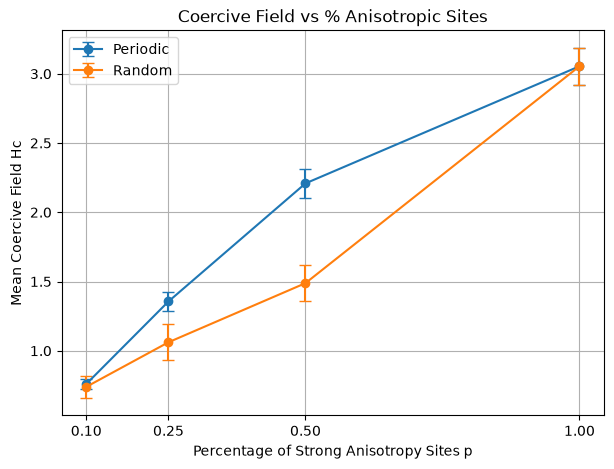

In [30]:
# Fraction of strongly anisotropic sites
pValues = np.array([0.10, 0.25, 0.50, 1.00])

# Periodic arrangements
periodicMean = np.array([
    np.mean(HcValues7),
    np.mean(HcValues3),
    np.mean(HcValues1),
    np.mean(HcValues5)])

periodicSTD = np.array([
    np.std(HcValues7),
    np.std(HcValues3),
    np.std(HcValues1),
    np.std(HcValues5)])

# Random arrangements
randomMean = np.array([
    np.mean(HcValues6),
    np.mean(HcValues4),
    np.mean(HcValues2),
    np.mean(HcValues5)])

randomSTD = np.array([
    np.std(HcValues6),
    np.std(HcValues4),
    np.std(HcValues2),
    np.std(HcValues5)])

plt.figure(figsize=(7,5))

plt.errorbar(pValues, periodicMean, yerr=periodicSTD, marker='o', capsize=4, label='Periodic')
plt.errorbar(pValues, randomMean, yerr=randomSTD, marker='o', capsize=4, label='Random')

plt.xlabel("Percentage of Strong Anisotropy Sites p")
plt.ylabel("Mean Coercive Field Hc")
plt.title("Coercive Field vs % Anisotropic Sites")

plt.xticks(pValues)
plt.grid()
plt.legend()
plt.show()

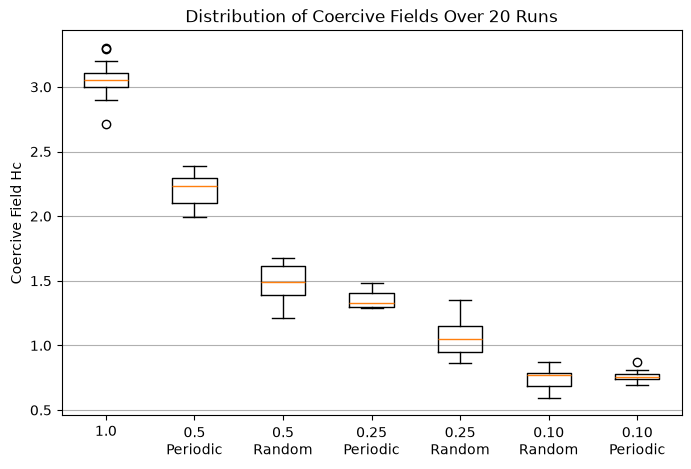

In [35]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        HcValues5,   # p=1 
        HcValues1,   # p=.5 checkerboard
        HcValues2,   # p=.5 random
        HcValues3,   # p=.25 periodic
        HcValues4,   # p=.25 random
        HcValues6,   # p=.10 random
        HcValues7    # p=.10 periodic
    ],
    tick_labels=[
        "1.0",
        "0.5\nPeriodic",
        "0.5\nRandom",
        "0.25\nPeriodic",
        "0.25\nRandom",
        "0.10\nRandom",
        "0.10\nPeriodic"
    ]
)

plt.ylabel("Coercive Field Hc")
plt.title("Distribution of Coercive Fields Over 20 Runs")
plt.grid(axis='y')
plt.show()

In [36]:
!jupyter nbconvert --to script "Heisenberg Model.ipynb"

[NbConvertApp] Converting notebook Heisenberg Model.ipynb to script
[NbConvertApp] Writing 10555 bytes to Heisenberg Model.py
